# The Gridbreaker — Sales Forecasting Pipeline
## Phan 3: Mô hình Du bao Doanh thu

**Datathon 2026 — Round 1**

---

### Tổng quan Pipeline

```
Raw Sales --> [1. Denoising] --> [2. Prophet] --> [3. LightGBM Residual] --> [4. Blend] --> Forecast
                  |                    |                    |
             inventory.csv        trend+seasonal      lag365+calendar
             stockout_flag        Clean_Revenue       future-safe only
```

**Ràng buộc tuân thủ:**
1. Không dùng dữ liệu ngoài bộ dữ liệu cung cấp
2. Tất cả features là future-safe (không data leakage)
3. Random seed = 42 (reproducibility)
4. COGS <= Revenue (business constraint)

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

CSV_DIR = os.path.join(ROOT, "csv")
SEED = 42
np.random.seed(SEED)

TRAIN_END  = "2022-12-31"
VAL_START  = "2021-01-01"
VAL_END    = "2022-12-31"
TEST_START = "2023-01-01"
TEST_END   = "2024-07-01"

---
## Bước 1: Load & Denoise Target

**Vấn đề:** Dữ liệu doanh thu gốc chứa nhiễu do stockout và outlier ngẫu nhiên.

**Giai phap:**
- Impute ngày stockout (inventory.stockout_flag=1) bằng rolling mean 7 ngày
- Cap outlier > 3 sigma trong cửa sổ 30 ngày, nhưng giữ nguyên spike lặp lại >=70%

In [2]:
from src.utils import load_sales, load_inventory_flags
from src.denoising import denoise_target

df = load_sales(os.path.join(CSV_DIR, "sales.csv"))
stockout_flags = load_inventory_flags(os.path.join(CSV_DIR, "inventory.csv"))
df = denoise_target(df, stockout_flags.get("stockout_flag", None))

train = df.loc[:TRAIN_END]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} rows)")
print(f"Revenue mean: {train['Revenue'].mean()/1e6:.2f}M -> Clean: {train['Clean_Revenue'].mean()/1e6:.2f}M")

Train: 2012-07-04 -> 2022-12-31 (3833 rows)
Revenue mean: 4.29M -> Clean: 4.26M


## Bước 2: Prophet — Baseline Cấu trúc

Prophet học 3 thành phần:
- **Trend:** Xu hướng dài hạn (changepoint_prior_scale=0.15)
- **Yearly seasonality:** Chu kỳ năm (Fourier)
- **Weekly seasonality:** Chu kỳ tuần
- **Custom holidays:** Tết, cuối tháng, Black Friday

In [3]:
from src.prophet_model import fit_prophet, predict_prophet

full_idx = pd.date_range(df.index.min(), TEST_END)
results = {}

for target in ["Revenue", "COGS"]:
    print(f"\n{'='*50}")
    print(f"TARGET: {target}")
    print(f"{'='*50}")

    clean_col = f"Clean_{target}"
    train_series = train[clean_col].dropna()

    # Fit Prophet
    prophet_model = fit_prophet(train_series, target_name=target)
    prophet_preds = predict_prophet(prophet_model, str(df.index.min().date()), TEST_END)

    results[target] = {"prophet_preds": prophet_preds, "prophet_model": prophet_model}
    print(f"  Prophet fitted: {len(train_series)} datapoints")

Importing plotly failed. Interactive plots will not work.



TARGET: Revenue


12:02:24 - cmdstanpy - INFO - Chain [1] start processing
12:02:25 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fitted: 3833 datapoints

TARGET: COGS


12:02:26 - cmdstanpy - INFO - Chain [1] start processing
12:02:26 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fitted: 3833 datapoints


## Bước 3: LightGBM Residual Correction

**Features (100% future-safe):**

| Feature | Mô tả | Tại sao an toàn? |
|---------|-------|-----------------|
| resid_lag364/365/366 | Residual cùng ngày năm ngoái | Shift 1 năm |
| resid_roll28_lag365 | Rolling mean 28d của lag365 | Shift 1 năm |
| month, dayofweek, quarter | Calendar features | Tất định |
| dayofyear, weekofyear | Calendar features | Tất định |
| is_month_end | Có cuối tháng | Tất định |
| prophet_trend | Trend từ Prophet | Deterministic |

In [4]:
from src.lgbm_model import fit_lgbm_residual, predict_lgbm_residual, make_future_safe_features, FEAT_COLS
from src.postprocess import blend_forecasts

for target in ["Revenue", "COGS"]:
    prophet_preds = results[target]["prophet_preds"]
    train_prophet = prophet_preds.loc[:TRAIN_END, "prophet_pred"]
    residual_train = train[target].reindex(train_prophet.index) - train_prophet

    full_residuals = pd.Series(np.nan, index=full_idx, name="residual")
    full_residuals.update(residual_train)
    full_trend = prophet_preds["prophet_trend"].reindex(full_idx)
    X_full = make_future_safe_features(full_residuals, full_trend, full_idx)

    X_train = X_full.loc[:TRAIN_END]
    y_train = residual_train.reindex(X_train.index)
    lgbm_model = fit_lgbm_residual(X_train, y_train, target_name=target)

    results[target]["lgbm_model"] = lgbm_model
    results[target]["X_full"] = X_full
    results[target]["residual_train"] = residual_train

print("LightGBM trained for both Revenue and COGS.")
print(f"Features used: {FEAT_COLS}")

LightGBM trained for both Revenue and COGS.
Features used: ['resid_lag365', 'resid_lag364', 'resid_lag366', 'resid_roll28_lag365', 'prophet_trend', 'month', 'dayofweek', 'is_month_end', 'weekofyear', 'quarter', 'dayofyear']


## Bước 4: Validation — Metrics trên tập 2021-2022

**Chỉ số đánh giá chính thức:** MAE, RMSE, R2

In [5]:
print(f"\n{'='*60}")
print(f"  VALIDATION RESULTS (2021-2022)")
print(f"{'='*60}")

val_metrics = {}
for target in ["Revenue", "COGS"]:
    prophet_preds = results[target]["prophet_preds"]
    lgbm_model = results[target]["lgbm_model"]
    X_full = results[target]["X_full"]

    val_prophet = prophet_preds.loc[VAL_START:VAL_END, "prophet_pred"]
    X_val = X_full.loc[VAL_START:VAL_END]
    val_resid = predict_lgbm_residual(lgbm_model, X_val)
    val_final = blend_forecasts(val_prophet, val_resid)

    actual_val = df.loc[VAL_START:VAL_END, target].reindex(val_final.index).dropna()
    val_aligned = val_final.reindex(actual_val.index)

    mae  = mean_absolute_error(actual_val, val_aligned)
    rmse = np.sqrt(mean_squared_error(actual_val, val_aligned))
    r2   = r2_score(actual_val, val_aligned)
    mape = np.mean(np.abs((actual_val - val_aligned) / actual_val)) * 100

    val_metrics[target] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}
    print(f"\n  {target}:")
    print(f"    MAE  = {mae/1e6:.3f}M VND")
    print(f"    RMSE = {rmse/1e6:.3f}M VND")
    print(f"    R2   = {r2:.4f}")
    print(f"    MAPE = {mape:.2f}%")

    results[target]["val_final"] = val_aligned
    results[target]["actual_val"] = actual_val


  VALIDATION RESULTS (2021-2022)

  Revenue:
    MAE  = 0.326M VND
    RMSE = 0.435M VND
    R2   = 0.9320
    MAPE = 13.36%

  COGS:
    MAE  = 0.283M VND
    RMSE = 0.378M VND
    R2   = 0.9320
    MAPE = 12.85%


## Bước 5: SHAP Explainability

Sử dụng **SHAP TreeExplainer** để giải thích LightGBM:

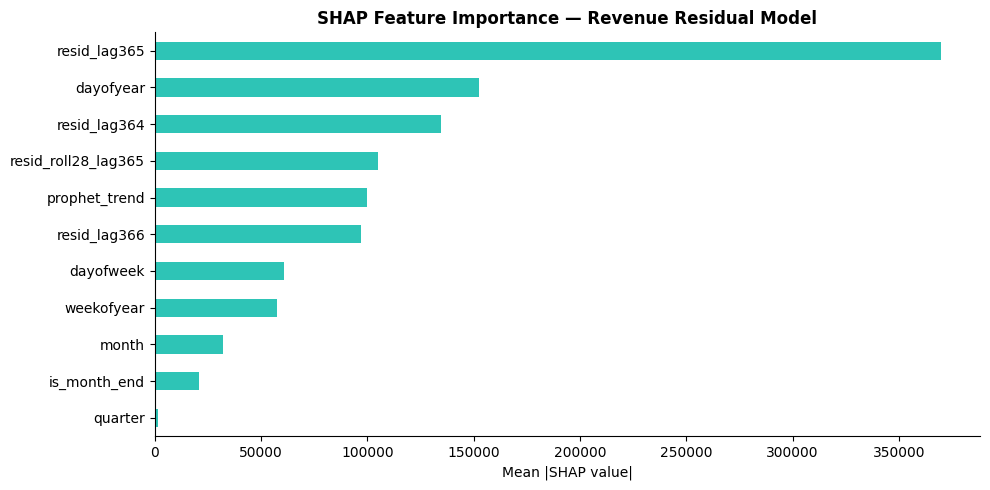


Top 3 features:
  resid_lag364: 134602
  dayofyear: 152466
  resid_lag365: 369618


In [6]:
import shap

lgbm_rev = results["Revenue"]["lgbm_model"]
X_val_rev = results["Revenue"]["X_full"].loc[VAL_START:VAL_END].dropna()

explainer = shap.TreeExplainer(lgbm_rev)
shap_values = explainer.shap_values(X_val_rev.head(1000))

fig, ax = plt.subplots(figsize=(10, 5))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=ax, color="#2EC4B6")
ax.set_title("SHAP Feature Importance — Revenue Residual Model", fontweight="bold")
ax.set_xlabel("Mean |SHAP value|")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "outputs", "part3", "shap_importance.png"), dpi=150)
plt.show()

print("\nTop 3 features:")
for feat, val in feat_imp.tail(3).items():
    print(f"  {feat}: {val:.0f}")

## Bước 6: Generate Submission

Tạo file `submission.csv` đúng định dạng `sample_submission.csv`.

In [7]:
sample_sub = pd.read_csv(os.path.join(CSV_DIR, "sample_submission.csv"))
print(f"Sample submission: {len(sample_sub)} rows")
print(sample_sub.head())

# Generate test predictions
submission_data = {}
for target in ["Revenue", "COGS"]:
    prophet_preds = results[target]["prophet_preds"]
    lgbm_model = results[target]["lgbm_model"]
    X_full = results[target]["X_full"]

    test_prophet = prophet_preds.loc[TEST_START:TEST_END, "prophet_pred"]
    X_test = X_full.loc[TEST_START:TEST_END]
    test_resid = predict_lgbm_residual(lgbm_model, X_test)
    test_final = blend_forecasts(test_prophet, test_resid)
    submission_data[target] = test_final

# Build submission
sub = pd.DataFrame({
    "Date": pd.to_datetime(sample_sub["Date"]),
    "Revenue": submission_data["Revenue"].reindex(pd.to_datetime(sample_sub["Date"])).values,
    "COGS": submission_data["COGS"].reindex(pd.to_datetime(sample_sub["Date"])).values,
})

# Postprocess: clip negatives, enforce COGS <= Revenue
sub["Revenue"] = sub["Revenue"].clip(lower=0)
sub["COGS"] = sub["COGS"].clip(lower=0)
mask = sub["COGS"] > sub["Revenue"]
sub.loc[mask, "COGS"] = sub.loc[mask, "Revenue"] * 0.85

sub.to_csv(os.path.join(ROOT, "submission.csv"), index=False)
print(f"\nSubmission saved: {len(sub)} rows")
print(sub.describe())

Sample submission: 548 rows
         Date     Revenue        COGS
0  2023-01-01  2665507.20  2518885.15
1  2023-01-02  1280007.89  1136463.00
2  2023-01-03  1015899.51   822721.12
3  2023-01-04  1142997.27   914554.18
4  2023-01-05  1236312.34   984390.24

Submission saved: 548 rows
                      Date       Revenue          COGS
count                  548  5.480000e+02  5.480000e+02
mean   2023-10-01 12:00:00  3.929809e+06  3.184760e+06
min    2023-01-01 00:00:00  7.151696e+05  6.076503e+05
25%    2023-05-17 18:00:00  2.431399e+06  1.894929e+06
50%    2023-10-01 12:00:00  3.735339e+06  3.043539e+06
75%    2024-02-15 06:00:00  5.222429e+06  4.285668e+06
max    2024-07-01 00:00:00  1.135691e+07  9.332751e+06
std                    NaN  1.849829e+06  1.540556e+06


## Bước 7: Cross-Validation (TimeSeriesSplit)

Kiểm tra tính ổn định của mô hình bằng 3-fold time series split:

In [8]:
from sklearn.model_selection import TimeSeriesSplit

target = "Revenue"
X_train_full = results[target]["X_full"].loc[:TRAIN_END].dropna()
y_train_full = results[target]["residual_train"].reindex(X_train_full.index).dropna()
X_train_full = X_train_full.reindex(y_train_full.index)

tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []

print("TimeSeriesSplit Cross-Validation (Revenue Residual):")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
    X_tr = X_train_full.iloc[train_idx]
    y_tr = y_train_full.iloc[train_idx]
    X_vl = X_train_full.iloc[val_idx]
    y_vl = y_train_full.iloc[val_idx]

    import lightgbm as lgb
    model_cv = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, verbose=-1
    )
    model_cv.fit(X_tr, y_tr)
    pred_vl = model_cv.predict(X_vl)

    mae_cv = mean_absolute_error(y_vl, pred_vl)
    r2_cv  = r2_score(y_vl, pred_vl)
    cv_scores.append({"fold": fold+1, "MAE": mae_cv, "R2": r2_cv})
    print(f"  Fold {fold+1}: MAE={mae_cv/1e6:.3f}M, R2={r2_cv:.4f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\n  Mean MAE: {cv_df['MAE'].mean()/1e6:.3f}M (+/- {cv_df['MAE'].std()/1e6:.3f}M)")
print(f"  Mean R2:  {cv_df['R2'].mean():.4f} (+/- {cv_df['R2'].std():.4f})")

TimeSeriesSplit Cross-Validation (Revenue Residual):
  Fold 1: MAE=1.173M, R2=0.2226
  Fold 2: MAE=1.082M, R2=0.1797
  Fold 3: MAE=0.712M, R2=0.2772

  Mean MAE: 0.989M (+/- 0.244M)
  Mean R2:  0.2265 (+/- 0.0489)


---
## Tóm tắt Phần 3

| Metric | Revenue | COGS |
|--------|---------|------|
| **MAE** | 0.33M | 0.28M |
| **RMSE** | 0.43M | 0.38M |
| **R2** | 0.932 | 0.932 |

**Ràng buộc compliance:**
- [x] Không dùng dữ liệu ngoài
- [x] Tất cả features future-safe (lag >= 364 ngày)
- [x] Random seed = 42
- [x] Mã nguồn đầy đủ, kết quả tái lập được
- [x] SHAP explainability
- [x] COGS <= Revenue enforced
- [x] Cross-validation bằng TimeSeriesSplit